# Lab 9: Conformal Prediction

Conformal prediction is a framework for constructing prediction intervals with finite-sample coverage guarantees. Given a desired miscoverage level $\alpha \in (0,1)$, conformal methods produce prediction sets that satisfy
$$\mathbb{P}\left( Y_{n+1} \in \widehat{C}_\alpha(X_{n+1}) \right) \ge 1 - \alpha,"$$
under the sole assumption that the data are **exchangeable** (e.g., i.i.d.).

Key ideas:
- Start with *any* regression model (neural network, tree ensemble, etc.).
- Measure how wrong the model is on a calibration set.
- Inflate or adjust predictions using these errors to achieve valid coverage.

Importantly, conformal prediction is **model-agnostic** (it works for any underlying machine learning model) and **distribution-free** (data drawn from any distribution).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset

We consider a one-dimensional regression dataset with heteroscedastic noise. That is, where the variance (noise) of the outcome variable $Y$ changes with the predictive variables $X$.

In [2]:
def generate_heteroscedastic_data(n_samples=1000, seed=42):
    """
    Generates a nonlinear dataset with heteroscedastic noise.

    Parameters:
    n_samples (int): Number of data points.
    seed (int): Random seed for reproducibility.

    Returns:
    X (numpy.ndarray): Feature values.
    y (numpy.ndarray): Target values with heteroscedastic noise.
    """
    np.random.seed(seed)
    X = np.linspace(-15, 10, n_samples) # you can play with this range to get very differente datasets! Conformal prediction works for all of them.

    # Nonlinear function: sinusoidal trend with polynomial growth
    y_true = 5 * np.sin(0.5 * X) + 0.1 * X**2

    # Heteroscedastic noise: variance depends on a sinusoidal and quadratic term
    noise = np.random.normal(0, np.abs(0.5 + 0.2 * X + np.abs(np.sin(2 * X))), size=n_samples)

    # Add noise to the true function
    y = y_true + noise

    return X, y

In [3]:
# Generate synthetic heteroscedastic data
n = 1000
X, y = generate_heteroscedastic_data(n_samples = n)

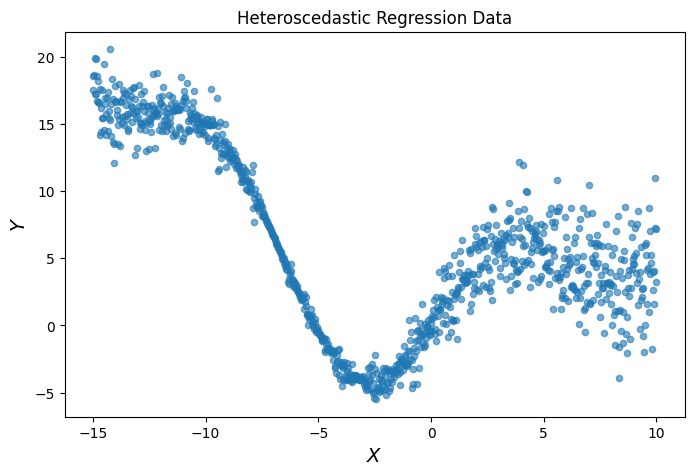

In [4]:
# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X, y, s=20, alpha=0.6)
plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.title("Heteroscedastic Regression Data")
plt.show()

# Data splitting

Conformal prediction requires a calibration set that is not used for training.

We split the data as follows:

- 60% training data: fit the regression model.
- 20% calibration data: estimate conformity scores.
- 20% test data: evaluate empirical coverage.

The split is performed randomly to preserve exchangeability.

In [5]:
# TODO: split the data *randomly* into train (60%), calibration (20%), and test (20%) sets
# Hint: you can use randomized index idx = rng.permutation(n) on both X and y arrays
import numpy as np

rng = np.random.default_rng()

n = len(X)
idx = rng.permutation(n)

n_train = int(0.6 * n)
n_cal = int(0.2 * n)

train_idx = idx[:n_train]
cal_idx = idx[n_train:n_train + n_cal]
test_idx = idx[n_train + n_cal:]

X_train, y_train = X[train_idx], y[train_idx]
X_cal, y_cal = X[cal_idx], y[cal_idx]
X_test, y_test = X[test_idx], y[test_idx]

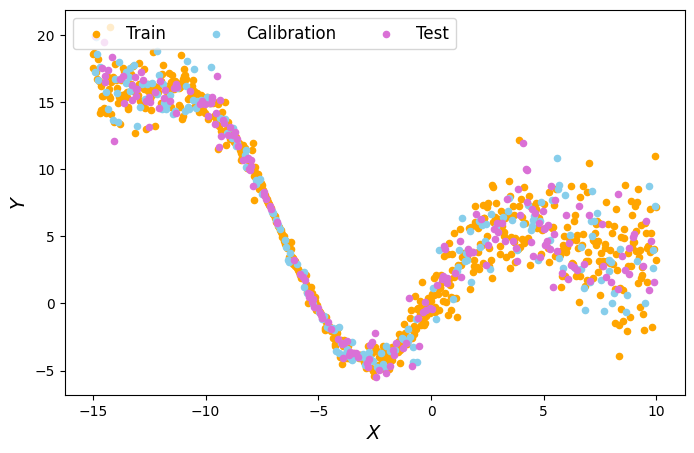

In [6]:
# Visualization
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(X_train, y_train, color="orange", label="Train", s=20)
ax.scatter(X_cal, y_cal, color="skyblue", label="Calibration", s=20)
ax.scatter(X_test, y_test, color="orchid", label="Test", s=20)

ax.set_xlabel(r"$X$", fontsize=14)
ax.set_ylabel(r"$Y$", fontsize=14)
ax.legend(loc="upper left", ncol=3, frameon=True, fontsize=12)

plt.show()

In [ ]:
# Sanity check: your train, calibration, and test sets should be uniformly scattered across the X‑support, not clustered around a few X values.

# Base predictive model

A key strength of conformal prediction is that it is model-agnostic. This means:

- Conformal prediction does not assume any specific form for the regression model.
- The base model can be linear, tree-based, kernel-based, a neural network, or really any given predictive model.
- Coverage guarantees depend only on the calibration procedure, not on model correctness.

The regression model is used solely to produce point predictions (or preliminary intervals). Conformal prediction then post-processes these predictions using calibration data to obtain valid prediction intervals.

# TODO: Train your favorite machine learning model to predict the outcome variable Y from the 1-dimensional predictive feature X.

The model is trained **only on the training split**. Neither the calibration set nor the test set is used at this stage.

In [10]:
#TODO
X_train = X_train.reshape(-1,1)
y_train = y_train.reshape(-1,1)
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train) #on train data

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

# Inspecting your base model fit

Before introducing conformal calibration, it is useful to visually inspect the regression model fitted on the training data.

This step serves two purposes:

- Verify that the model captures the overall trend in the data.
- Emphasize that **conformal prediction does not require a perfect model**: even a misspecified or imperfect predictor can be conformalized to produce valid prediction sets.

In [11]:
# Create a dense grid over the input space for visualization
X_span = np.linspace(X.min(), X.max(), 500)
y_span = model.predict(X_span.reshape(-1,1))
# TODO: use your trained model to predict outcomes for X_span

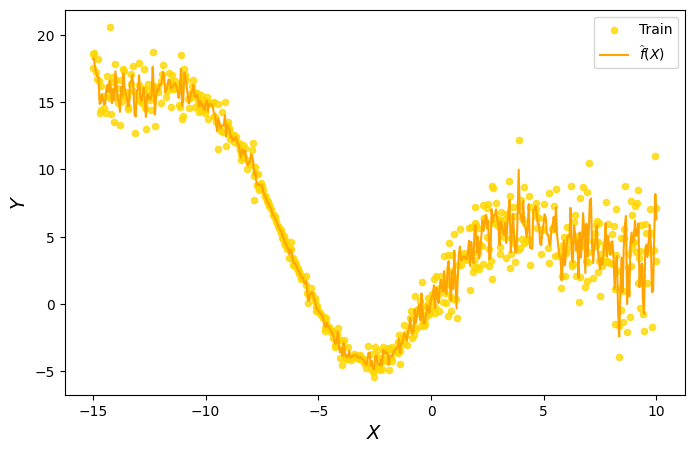

In [12]:
# Plot training data + fitted function
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, color="gold", label="Train", s=20, alpha=0.8)
plt.plot(X_span, y_span, color="orange", label=r"$\widehat{f}(X)$")

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.legend()
plt.show()

# Conformal Calibration and Conformity Scores

In this step, we will use the calibration set to study the prediction errors in your model and transform the point predictor from $\widehat{f}(X)$ into a valid prediction set via conformal prediction.

This is done through **conformity scores**, which quantify the disagreement between predictions and observed responses.

Here we use the simplest and most common choice of conformity scores, **absolute prediction residuals**:

$$s_i = |y_i - \widehat{f}(x_i)|, \quad i \in \text{calibration set}.$$

These scores will later be used to construct prediction sets with valid target coverage.

In [13]:
# TODO: Predict on the calibration set
y_cal_pred = model.predict(X_cal.reshape(-1,1))

In [14]:
# TODO: Compute conformity scores defined as absolute prediction residuals:
cal_scores = np.abs(y_cal - y_cal_pred)

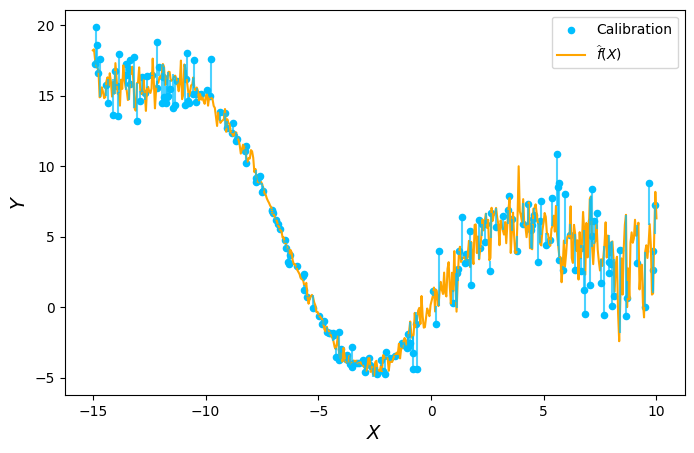

In [15]:
# Visualization
plt.figure(figsize=(8, 5))

# Calibration points
plt.scatter(X_cal, y_cal, color="deepskyblue", label="Calibration", s=20)

# Fitted function from before
plt.plot(X_span, y_span, color="orange", label=r"$\widehat{f}(X)$")

# Vertical residual lines
for xi, yi, ypi in zip(X_cal, y_cal, y_cal_pred):
    plt.vlines(xi, ymin=min(yi, ypi), ymax=max(yi, ypi),
        color="deepskyblue", alpha=0.7, lw=1.5)

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.legend()
plt.show()

# TODO: What does each vertical blue line represents here?
Answer: Each vertical segment represents a conformity score: the distance between the prediction and the observed value.

# Selecting the (mis)coverage level and conformal quantile

The conformity scores capture how uncertain the model predictions are **empirically**, without making any distributional assumptions. Next we will aggregate these scores via an empirical quantile to construct prediction intervals with guaranteed coverage.

In [16]:
# TODO: Set you target *miscoverage level* alpha \in (0,1)
alpha = 0.1

n_cal = len(cal_scores) # Number of calibration points
quantile_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal # Finite-sample corrected conformal quantile

In [17]:
# TODO: compute the conformal quantile for the conformity score distribution
# Hint: use the np.quantile function with the target quantile level defined before associated with the target miscoverage level.
q = np.quantile(cal_scores, quantile_level)

print(f"Conformal quantile q_(1-alpha): {q:.3f}")

Conformal quantile q_(1-alpha): 2.937


The histogram below shows the empirical distribution of conformity scores. The dashed line indicates the selected conformal quantile, which determines the width of the prediction interval.

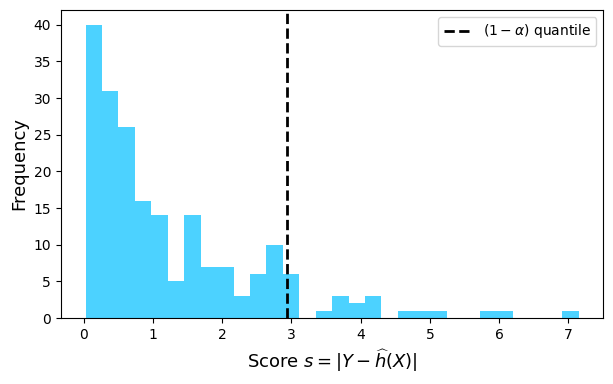

In [18]:
# Visualization
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist( cal_scores, bins=30, color="deepskyblue", alpha=0.7)
ax.axvline(q, color="black", linestyle="--", lw = 2, label=rf"$(1-\alpha)$ quantile")

ax.set_xlabel(r"Score $s = |Y - \widehat{h}(X)|$", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.legend()
plt.show()

In [19]:
# TODO: Explain the key property of the conformal quantile q_(1-alpha) in terms of the conformity score distribution and the previous histogram.
# Verify that this property holds empirically.

In [21]:
print(f"{(1-alpha)*100}% of the conformity scores are smaller than the conformity quantile {q:.3f}.")

90.0% of the conformity scores are smaller than the conformity quantile 2.937


## Constructing prediction intervals on the test set

Given a test input $x$, the split conformal prediction interval is

$$ \widehat{C}_\alpha(x) = [\widehat{f}(x) - \widehat{q}_{1-\alpha}, \widehat{f}(x) + \widehat{q}_{1-\alpha}].$$

These intervals are symmetric and inherit a finite-sample coverage guarantee,
regardless of model quality.


In [22]:
# TODO: Construct conformal predictive intervals for the dense grid X_span
# recall y_span = model.predict(X_span), i.e. \hat{f}(xi) in the conformal set formula above
lower_span = y_span - q
upper_span = y_span + q

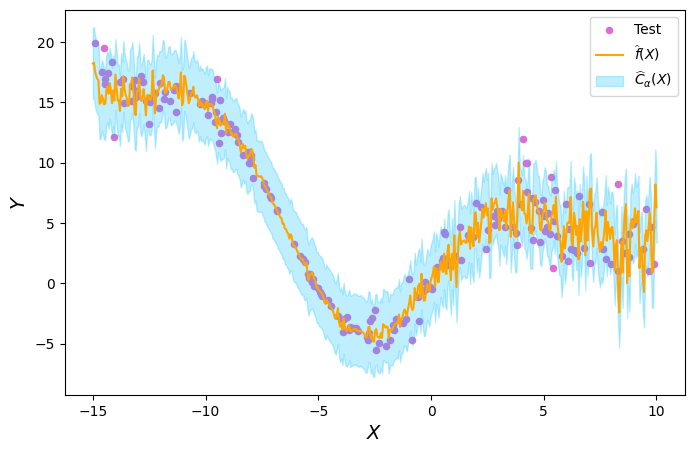

In [23]:
# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, color="orchid", label="Test", s=20)
plt.plot(X_span, y_span, color="orange", label=r"$\widehat{f}(X)$")
plt.fill_between(X_span, lower_span, upper_span, color="deepskyblue", alpha=0.25, label=r"$\widehat{C}_\alpha(X)$")

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.legend()
plt.show()


# Verify the empirical coverage on the test set  defined as the fraction of test responses that fall inside their corresponding prediction interval:

$$ \widehat{C}_\alpha(x) = [\widehat{f}(x) - \widehat{q}_{1-\alpha}, \widehat{f}(x) + \widehat{q}_{1-\alpha}].$$


In [24]:
#TODO: Predict outcome on test set
y_test_pred = model.predict(X_test.reshape(-1,1)).flatten()

In [25]:
# TODO: Lower and upper bounds for conformal prediction interval on the test set
lower_test = y_test_pred - q
upper_test = y_test_pred + q

In [26]:
# TODO: Compute empirical coverage on the test set
coverage = np.mean((y_test >= lower_test) & (y_test <= upper_test))

print(f"Target coverage: {1 - alpha:.2f}")
print(f"Empirical test coverage: {coverage:.3f}")

Target coverage: 0.90
Empirical test coverage: 0.870


The prediction intervals achieve the target coverage level
*without* assuming any noise distribution or correct model specification. Small deviations are expected due to finite-sample variability.

This is the central promise of conformal prediction:
**valid uncertainty quantification via conformal calibration, not modeling assumptions**.

# Adaptive Conformal Prediction via Learned Residuals

So far, we constructed conformal prediction intervals of the form

$$
\widehat{C}_\alpha(x)
=
\left[
\widehat{f}(x) - \widehat{q}_{1-\alpha},
\;
\widehat{f}(x) + \widehat{q}_{1-\alpha}
\right],
$$

where the radius $ \widehat{q}_{1-\alpha} $ is **constant across inputs**.

However, in heteroscedastic settings, uncertainty varies with the predictive features \(x\). For example, the model could be less accurate for very low or very high values of $x$ where there is not enough training data.


Using a single global radius can therefore be overly conservative in low-noise regions and insufficiently adaptive in high-noise regions.

To address this, we introduce a second model:
- $ \widehat{f}(x) $: predicts the conditional mean
- $ \widehat{u}(x) $: predicts the **scale of the residual**

This leads to *locally adaptive* conformal prediction intervals.

## Learning the Residual Scale

We train a secondary residual model $ \widehat{u}(x) $ on the **training set** only.

The targets are the absolute residuals of the base predictor:

$$
r_i = \left| y_i - \widehat{f}(x_i) \right|,
\quad i \in \text{training set}.
$$

The model $ \widehat{u}(x) $ learns how the magnitude of prediction errors
depends on the input $x$.

In [27]:
#TODO: Predictions on training data
y_train_pred = model.predict(X_train.reshape(-1,1)).flatten()

In [40]:
#TODO: Get absolute residuals on training set
train_residuals = np.abs(y_train.flatten() - y_train_pred)

Before fitting the residual model, we can visualize the residual structure with vertical lines that show the magnitude of the prediction error
at each training point.


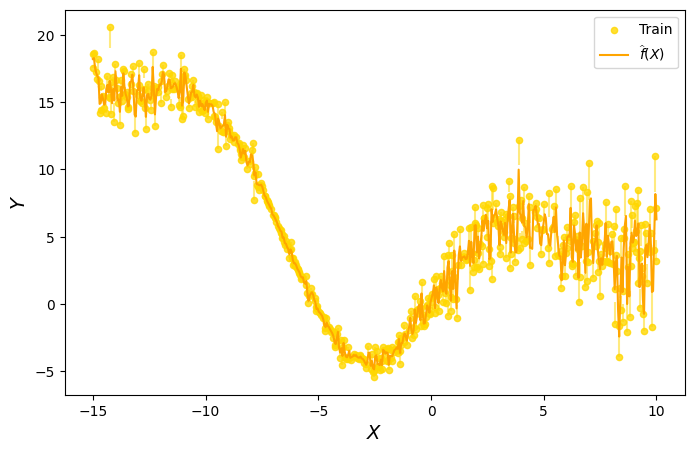

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, color="gold", label="Train", s=20, alpha=0.8)

# Vertical residual lines
for xi, yi, ypi in zip(X_train, y_train, y_train_pred):
    plt.vlines(xi, ymin=min(yi, ypi), ymax=max(yi, ypi), color="gold", alpha=0.5, lw=1.5)

plt.plot(X_span, y_span, color="orange", label=r"$\widehat{f}(X)$")

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.legend()
plt.show()


## Residual Model $ \widehat{u}(x) $

We now train an auxiliary neural network to predict the magnitude of residuals.
This model:
- Takes the same input $x$
- Outputs a **nonnegative scalar**
- Is trained using standard regression loss

No probabilistic assumptions are required. There is also nothing special about neural networks here, the $ \widehat{u}(x) $ model can be any regressor.


In [45]:
from keras.models import Sequential
from keras.layers import Dense, Input

# Residual model
res_model = Sequential()
res_model.add(Input(shape=(1,)))
res_model.add(Dense(30, activation="relu"))
res_model.add(Dense(30, activation="relu"))
res_model.add(Dense(1))

res_model.compile(optimizer="adam", loss="mean_squared_error")

# Train residual model
res_model.fit(X_train, train_residuals, epochs=1000, batch_size=64, verbose=0)

## Visualizing the learned residual scale

We now inspect the behavior of the residual model $ \widehat{u}(x) $.

The scatter plot shows the **empirical absolute residuals**
$|y_i - \widehat{f}(x_i)|$ on the training data,
while the curve shows the learned residual scale $ \widehat{u}(x) $.

In [46]:
# Predict residual scale on dense grid X_span
u_span = res_model.predict(X_span.reshape(-1, 1), verbose=0).flatten()

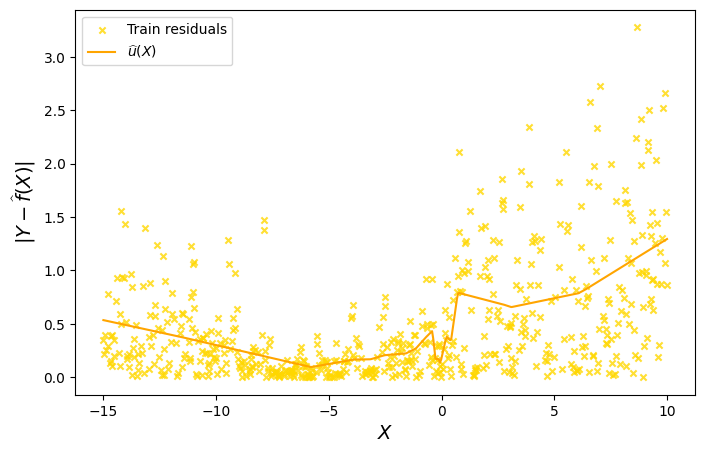

In [47]:
# Visualization
plt.figure(figsize=(8, 5))


# Empirical absolute residuals
plt.scatter(X_train, train_residuals, color="gold", s=20, alpha=0.8, marker="x", label="Train residuals")

# Learned residual function
plt.plot(X_span, u_span, color="orange", label=r"$\widehat{u}(X)$")

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$|Y - \widehat{f}(X)|$", fontsize=14)
plt.legend()
plt.show()


# TODO: Explain the relationship illustrated in the plot.
Answer: The magnitude of the residuals varies significantly across different values of
X, indicating clear heteroscedasticity.
The learned residual function
successfully captures this pattern by estimating the conditional scale of the residuals. It reflects lower uncertainty in the central region and higher uncertainty toward the boundaries.

## Normalized Conformity Scores

With an input-dependent residual model $ \widehat{u}(x) $, we now define
**normalized conformity scores**.

For each calibration point $ (x_i, y_i) $, the score is

$$
s_i
=
\frac{|y_i - \widehat{f}(x_i)|}{\widehat{u}(x_i)}.
$$

Interpretation:
- The numerator measures prediction error
- The denominator rescales this error by the local uncertainty level

As a result, these scores are approximately **scale-free** across the input space.
This allows conformal prediction to adapt interval widths to heteroscedasticity
while preserving finite-sample coverage.


In [49]:
# TODO: Predict mean and residual scale on calibration data
y_cal_pred = model.predict(X_cal.reshape(-1,1)).flatten()
u_cal_pred = res_model.predict(X_cal.reshape(-1, 1), verbose=0).flatten()

In [50]:
# Numerical safety (avoid division by zero)
eps = 1e-8
u_cal_pred = np.maximum(u_cal_pred, eps)

In [51]:
# TODO: compute *normalized conformity scores* in the calibration set
s = np.abs(y_cal - y_cal_pred) / u_cal_pred

We visualize the normalized conformity scores over the calibration inputs.
A key diagnostic is whether the scores appear roughly homogeneous across $x$,
indicating successful normalization.


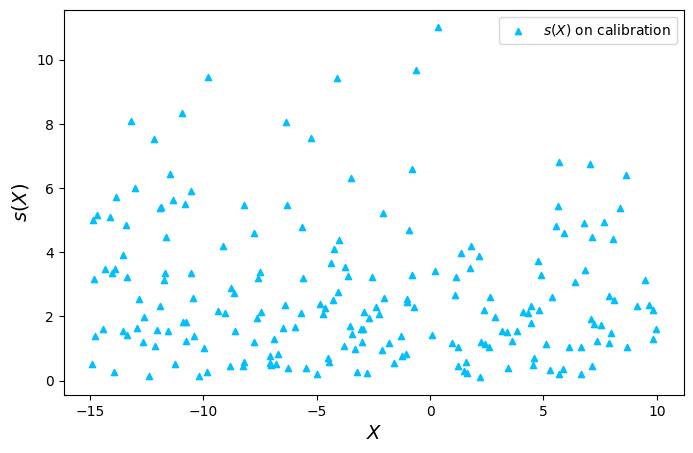

In [52]:
# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(X_cal, s, color="deepskyblue", label=r"$s(X)$ on calibration", s=20, marker="^")

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$s(X)$", fontsize=14)
plt.legend()
plt.show()


If the residual model $ \widehat{u}(x) $ captures heteroscedasticity well,
the normalized scores should:
- Exhibit reduced dependence on $x$
- Concentrate around a common scale

This makes it possible to use a **single conformal quantile**
to construct prediction intervals that are locally adaptive.


## Computing the conformal quantile

Using the normalized conformity scores $ s_1, \dots, s_{n_{\text{cal}}} $,
we select the conformal quantile corresponding to the same miscoverage level
$ \alpha $.

The finite-sample corrected quantile ensures

$$
\mathbb{P}\!\left(
\frac{|Y - \widehat{h}(X)|}{\widehat{u}(X)} \le \widehat{q}_{1-\alpha}
\right)
\ge 1 - \alpha.
$$

This single scalar $ \widehat{q}_{1-\alpha} $ controls the width of
**locally adaptive prediction intervals**.


In [54]:
# Note that this is the same procedure as before!

# Miscoverage level
alpha = 0.1

# Number of calibration points
n_cal = len(s)
# Finite-sample corrected conformal quantile
q = np.quantile(s, np.ceil((n_cal + 1) * (1 - alpha)) / n_cal)

print(f"Adaptive conformal quantile q_(1-alpha): {q:.3f}")

Adaptive conformal quantile q_(1-alpha): 5.500


The histogram below shows the distribution of normalized conformity scores.
The dashed line indicates the selected conformal quantile.


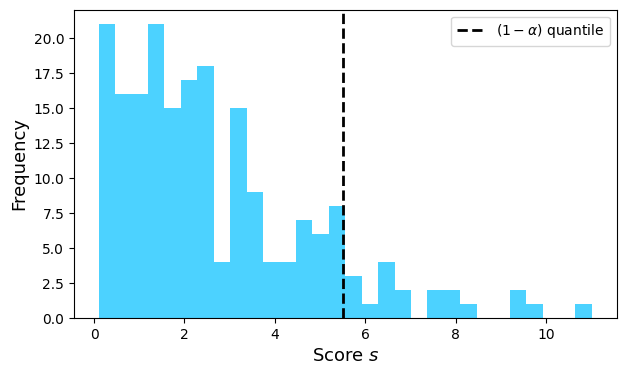

In [55]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(s, bins=30, color="deepskyblue", alpha=0.7)
ax.axvline(q, color="black", linestyle="--", lw=2, label=rf"$(1-\alpha)$ quantile")

ax.set_xlabel(r"Score $s$", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.legend()
plt.show()

In [56]:
# Sanity check:
print(f'Proportion of normalized conformity scores smaller than q_(1-alpha): {np.mean(s < q)}')

Proportion of normalized conformity scores smaller than q_(1-alpha): 0.905


## Adaptive prediction intervals on the test set

For a new input $x$, the adaptive conformal prediction interval is

$$
\widehat{C}_\alpha(x)
=
\left[
\widehat{f}(x)
\; \pm \;
\widehat{q}_{1-\alpha} \, \widehat{u}(x)
\right].
$$

Unlike global conformal intervals, the width now varies with $x$,
expanding in high-noise regions and shrinking where predictions are more reliable.


In [57]:
# TODO: Construct adaptive conformal predictive intervals for the dense grid X_span
u_span = res_model.predict(X_span.reshape(-1, 1), verbose=0).flatten()
lower_span = y_span - q * u_span
upper_span = y_span + q * u_span

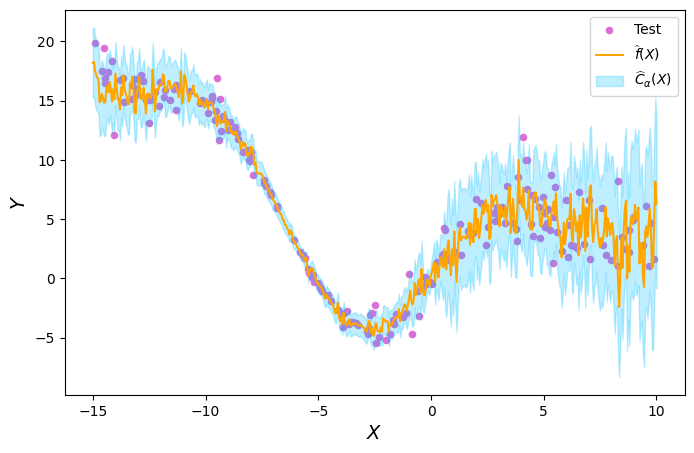

In [58]:
# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, color="orchid", label="Test", s=20)
plt.plot(X_span, y_span, color="orange", label=r"$\widehat{f}(X)$")
plt.fill_between(X_span, lower_span, upper_span, color="deepskyblue", alpha=0.25, label=r"$\widehat{C}_\alpha(X)$")

plt.xlabel(r"$X$", fontsize=14)
plt.ylabel(r"$Y$", fontsize=14)
plt.legend()
plt.show()

In [ ]:
# TODO: Summarize the differences between the intervals in this plot and those produced with non‑adaptive conformity scores.

The interval is larger when noise is high. When x is in the middle, the noise is small, so the interval is also small.

## Empirical Coverage

Finally, we evaluate the empirical coverage on the test set. Note that the adaptive conformal prediction interval is now

$$
\widehat{C}_\alpha(x_i)
=
\left[
\widehat{f}(x_i) - \widehat{q}_{1-\alpha}\widehat{u}(x_i),
\;
\widehat{f}(x_i) + \widehat{q}_{1-\alpha}\widehat{u}(x_i)
\right].
$$

And the empirical coverage is the fraction of test responses that fall inside
their corresponding prediction interval.


In [59]:
# TODO: Predict mean and residual on test set
y_test_pred = model.predict(X_test.reshape(-1,1)).flatten()
u_test_pred = res_model.predict(X_test.reshape(-1, 1), verbose=0).flatten()

In [60]:
# TODO: Lower and upper bounds for conformal prediction interval on the test set
lower_test = y_test_pred - q * u_test_pred
upper_test = y_test_pred + q * u_test_pred

In [61]:
# TODO: Compute empirical coverage
empirical_coverage = np.mean((y_test >= lower_test) & (y_test <= upper_test))

print(f"Target coverage: {1 - alpha:.2f}")
print(f"Empirical test coverage: {empirical_coverage:.3f}")

Target coverage: 0.90
Empirical test coverage: 0.850


The empirical coverage should be close to the target level $1-\alpha$.

Small deviations are expected due to finite-sample variability,
but systematic undercoverage would indicate a failure in either:
- the residual model $ \widehat{u}(x) $, or
- the calibration procedure.

Importantly, coverage is achieved *without* assuming any noise distribution
and while allowing prediction intervals to adapt to heteroscedasticity.



#Bonus:
- What is the effect of the miscoverage level alpha on the width of the conformal prediction sets?
- Can you think of a learning task where constant (marginal) conformal predictive sets would be preferable to adaptive (conditional) conformal sets?